In [1]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [4]:
# %% [Step 0] 40대 타겟 선정을 위한 업종별 매출 순위 확인

# 💡 추정매출 데이터에 있는 40대 매출 금액 컬럼을 사용합니다.
# (컬럼명이 정확히 맞는지 확인해 주세요. 만약 없다면 '당월_매출_금액'으로 전체 순위를 볼 수 있습니다.)
기준_컬럼 = '연령대_40_매출_금액' 

if 기준_컬럼 in sales.columns:
    print(f'✅ "{기준_컬럼}" 기준으로 40대 매출 순위를 집계합니다.\n')
    
    # 1. 40대 매출액 기준으로 업종별 집계 및 정렬
    업종별_순위 = sales.groupby('서비스_업종_코드_명')[기준_컬럼].sum().reset_index()
    업종별_순위 = 업종별_순위.sort_values(by=기준_컬럼, ascending=False).reset_index(drop=True)
    
    # 2. 비중 계산
    총매출_40대 = 업종별_순위[기준_컬럼].sum()
    업종별_순위['매출비중(%)'] = (업종별_순위[기준_컬럼] / 총매출_40대) * 100
    
    # 3. Top 15 출력
    print('🏆 서울시 40대 매출 집중 업종 Top 15')
    print('-' * 60)
    print(f'{"순위":<4} {"업종명":<15} {"40대 총매출액(원)":>18} {"비중(%)":>8}')
    print('-' * 60)
    
    for i in range(15):
        이름 = 업종별_순위.loc[i, "서비스_업종_코드_명"]
        매출 = 업종별_순위.loc[i, 기준_컬럼]
        비중 = 업종별_순위.loc[i, "매출비중(%)"]
        print(f'{i+1:<4} {이름:<15} {매출:>21,.0f} {비중:>7.1f}%')

else:
    print(f'❌ 데이터에 {기준_컬럼} 컬럼이 없습니다. sales.columns를 확인해 주세요.')

✅ "연령대_40_매출_금액" 기준으로 40대 매출 순위를 집계합니다.

🏆 서울시 40대 매출 집중 업종 Top 15
------------------------------------------------------------
순위   업종명                    40대 총매출액(원)    비중(%)
------------------------------------------------------------
1    한식음식점              12,570,851,791,073    11.8%
2    일반의류                9,171,552,457,461     8.6%
3    일반교습학원              9,148,899,124,130     8.6%
4    일반의원                7,672,604,067,002     7.2%
5    의약품                 6,190,570,872,280     5.8%
6    수산물판매               4,682,890,573,371     4.4%
7    슈퍼마켓                4,144,086,851,029     3.9%
8    편의점                 4,028,217,190,847     3.8%
9    컴퓨터및주변장치판매          3,532,695,105,753     3.3%
10   반찬가게                3,271,536,470,140     3.1%
11   청과상                 2,836,481,707,000     2.7%
12   육류판매                2,690,451,625,992     2.5%
13   커피-음료               2,643,016,961,965     2.5%
14   화장품                 2,541,177,771,851     2.4%
15   호프-간이주점             2,452,674

In [5]:
# %% 40대 상주인구 기반 상권 유형별 상관계수 분석 통합 코드

# 1. 40대 상주인구 비율 생성
df_상주['40대_상주_비율'] = df_상주['연령대_40_상주인구_수'].fillna(0) / df_상주['총_상주인구_수'].replace(0, np.nan) * 100

# 2. 상권별 당월 총매출 집계
총매출_df = sales.groupby(['기준_년분기_코드', '상권_코드'])['당월_매출_금액'].sum().reset_index(name='상권_총매출')

# 3. 💡 데이터 기반 Top 3 업종 적용!
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원'] 
타겟_매출 = sales[sales['서비스_업종_코드_명'].isin(타겟3_40대)]
타겟_피벗 = 타겟_매출.groupby(['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명'])['당월_매출_금액'].sum().unstack(fill_value=0).reset_index()

# 4. 데이터 병합 및 비중 계산
merged_df_40 = 총매출_df.merge(타겟_피벗, on=['기준_년분기_코드', '상권_코드'], how='left').fillna(0)
merged_df_40 = merged_df_40.merge(df_상주[['기준_년분기_코드', '상권_코드', '40대_상주_비율']], on=['기준_년분기_코드', '상권_코드'], how='inner')

# 파생변수: 개별 업종 비중 및 TOP3 합산 비중
업종1, 업종2, 업종3 = 타겟3_40대[0], 타겟3_40대[1], 타겟3_40대[2]

merged_df_40[f'{업종1}_비중'] = merged_df_40[업종1] / merged_df_40['상권_총매출'].replace(0, np.nan) * 100
merged_df_40[f'{업종2}_비중'] = merged_df_40[업종2] / merged_df_40['상권_총매출'].replace(0, np.nan) * 100
merged_df_40[f'{업종3}_비중'] = merged_df_40[업종3] / merged_df_40['상권_총매출'].replace(0, np.nan) * 100
merged_df_40['TOP3_합산_비중'] = merged_df_40[f'{업종1}_비중'] + merged_df_40[f'{업종2}_비중'] + merged_df_40[f'{업종3}_비중']

# 5. [에러방지] 상권_구분_코드_명 추가 병합
if '상권_구분_코드_명' not in merged_df_40.columns:
    merged_df_40 = merged_df_40.merge(
        df_상주[['상권_코드', '상권_구분_코드_명']].drop_duplicates(),
        on='상권_코드', 
        how='left'
    )

# 6. 상주인구 5구간 분할 (시각화용)
merged_df_40['40대_상주_5구간'] = pd.qcut(merged_df_40['40대_상주_비율'].dropna(), q=5, 
                               labels=['하위 20%', '20~40%', '40~60%', '60~80%', '상위 20%'], duplicates='drop')

# 7. '상권' 변수 고유 리스트 재정의
상권_리스트 = merged_df_40['상권_구분_코드_명'].dropna().unique()

# 8. 최종 텍스트 표 출력
print('\n📊 상권구분별 40대 상주인구 비율 vs 40대 Top3 업종(한식·의류·학원)')
print('-' * 95)
print(f'{"유형":<10} {"40대비율":>8} {업종1:>10} {업종2:>10} {업종3:>10} {"3업종합":>8} {"상관계수":>10}')
print('-' * 95)

for 구분 in 상권_리스트:
    sub = merged_df_40[merged_df_40['상권_구분_코드_명'] == 구분]
    
    if not sub.empty and len(sub) > 1:
        corr = sub[['40대_상주_비율', 'TOP3_합산_비중']].corr().iloc[0, 1]
        
        print(f'{구분:<10} {sub["40대_상주_비율"].mean():>7.1f}%'
              f' {sub[f"{업종1}_비중"].mean():>9.1f}%'
              f' {sub[f"{업종2}_비중"].mean():>9.1f}%'
              f' {sub[f"{업종3}_비중"].mean():>9.1f}%'
              f' {sub["TOP3_합산_비중"].mean():>7.1f}%'
              f' {corr:>9.3f}')
    else:
        print(f'{구분:<10} 데이터 부족으로 분석 제외')


📊 상권구분별 40대 상주인구 비율 vs 40대 Top3 업종(한식·의류·학원)
-----------------------------------------------------------------------------------------------
유형            40대비율      한식음식점       일반의류     일반교습학원     3업종합       상관계수
-----------------------------------------------------------------------------------------------
관광특구          14.1%      12.3%      24.2%       0.0%    36.6%     0.381
골목상권          14.3%      29.8%       3.0%       5.4%    38.2%    -0.008
발달상권          15.1%      19.5%       5.1%       4.1%    28.7%     0.106
전통시장          12.6%      22.2%       7.3%       1.3%    30.8%     0.056


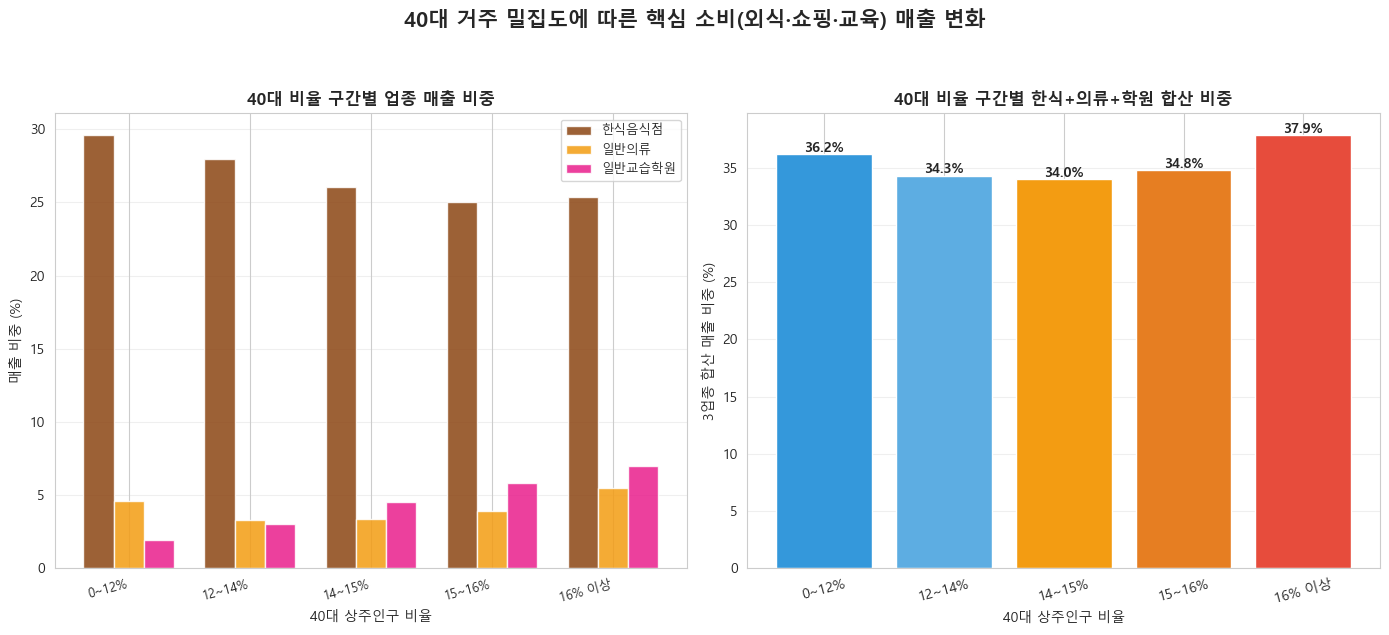

In [6]:
# %% 40대 상주 비율 5분위별 분석 및 시각화 (색상 동기화 버전)

# 1. 40대 상주 비율 5분위 구간 나누기 (실제 경곗값 bins 추출)
merged_df_40['40대_구간'], bins = pd.qcut(
    merged_df_40['40대_상주_비율'].dropna(), q=5, retbins=True, duplicates='drop'
)

# 2. 직관적인 구간 라벨 자동 생성
라벨 = [f'{bins[i]:.0f}~{bins[i+1]:.0f}%' for i in range(len(bins)-2)]
라벨.append(f'{bins[-2]:.0f}% 이상')

merged_df_40['40대_구간'] = pd.qcut(
    merged_df_40['40대_상주_비율'].dropna(), q=5, labels=라벨, duplicates='drop'
)
 
# 3. 구간별 평균 집계 (40대 타겟 업종 매핑)
구간별_40 = merged_df_40.groupby('40대_구간').agg(
    평균40대=('40대_상주_비율', 'mean'),
    한식=('한식음식점_비중', 'mean'),
    의류=('일반의류_비중', 'mean'),
    학원=('일반교습학원_비중', 'mean'),
    합계=('TOP3_합산_비중', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

# ==========================================
# 4. 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 업종별 분리 (좌측 차트)
ax1 = axes[0]
x = np.arange(len(구간별_40))
w = 0.25

# 💡 시각적 통일성을 위해 기존 색상 유지 (브라운, 오렌지, 핑크)
ax1.bar(x - w, 구간별_40['한식'], w, color='#8B4513', alpha=0.85, label='한식음식점')
ax1.bar(x, 구간별_40['의류'], w, color='#F39C12', alpha=0.85, label='일반의류')
ax1.bar(x + w, 구간별_40['학원'], w, color='#E91E8C', alpha=0.85, label='일반교습학원')

ax1.set_xticks(x)
ax1.set_xticklabels(구간별_40['40대_구간'], fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_xlabel('40대 상주인구 비율')
ax1.set_title('40대 비율 구간별 업종 매출 비중', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
 
# (2) 3업종 합산 (우측 차트)
ax2 = axes[1]
# 💡 그라데이션 색상 동일하게 적용
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax2.bar(구간별_40['40대_구간'], 구간별_40['합계'], color=colors, edgecolor='white')

ax2.set_ylabel('3업종 합산 매출 비중 (%)')
ax2.set_xlabel('40대 상주인구 비율')
ax2.set_title('40대 비율 구간별 한식+의류+학원 합산 비중', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)
 
# 막대 위 수치 텍스트 표시
for bar, val in zip(bars, 구간별_40['합계']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
plt.suptitle('40대 거주 밀집도에 따른 핵심 소비(외식·쇼핑·교육) 매출 변화', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [7]:
# %% 40대 핵심 3업종 간 상관관계 + 상권 유형 비교

# 1. 3업종 간 상관관계 분석
# (앞선 코드에서 생성한 40대 전용 컬럼명 사용)
corr_3_40 = merged_df_40[['한식음식점_비중', '일반의류_비중', '일반교습학원_비중']].corr()
 
print('📊 40대 핵심 3업종 간 상관관계')
print(corr_3_40.round(3))
 
# 2. 업종별 비중 상위 20% 상권 데이터 추출
한식_상위_40 = merged_df_40[merged_df_40['한식음식점_비중'] > merged_df_40['한식음식점_비중'].quantile(0.8)]
의류_상위_40 = merged_df_40[merged_df_40['일반의류_비중'] > merged_df_40['일반의류_비중'].quantile(0.8)]
학원_상위_40 = merged_df_40[merged_df_40['일반교습학원_비중'] > merged_df_40['일반교습학원_비중'].quantile(0.8)]
 
# 3. 상위 상권 프로필 비교 출력
print('\n📊 40대 타겟 업종별 상위 20% 상권 프로필 비교')
print(f'{"":>12} {"40대비율":>8} {"한식":>8} {"의류":>8} {"학원":>8} {"상권구성":>30}')
print('-' * 85)

for name, df in [('한식 상위', 한식_상위_40), ('의류 상위', 의류_상위_40), ('학원 상위', 학원_상위_40)]:
    # 상권 구분(골목, 발달, 전통시장 등) 비율 추출
    구성 = df['상권_구분_코드_명'].value_counts(normalize=True).head(3)
    구성str = ', '.join([f'{k} {v*100:.0f}%' for k, v in 구성.items()])
    
    # 간격에 맞추어 40대 전용 데이터 출력
    print(f'{name:>12} {df["40대_상주_비율"].mean():>7.1f}%'
          f' {df["한식음식점_비중"].mean():>7.1f}%'
          f' {df["일반의류_비중"].mean():>7.1f}%'
          f' {df["일반교습학원_비중"].mean():>7.1f}%'
          f' {구성str:>30}')

📊 40대 핵심 3업종 간 상관관계
           한식음식점_비중  일반의류_비중  일반교습학원_비중
한식음식점_비중       1.00    -0.16      -0.16
일반의류_비중       -0.16     1.00      -0.07
일반교습학원_비중     -0.16    -0.07       1.00

📊 40대 타겟 업종별 상위 20% 상권 프로필 비교
                40대비율       한식       의류       학원                           상권구성
-------------------------------------------------------------------------------------
       한식 상위    13.9%    69.7%     1.7%     1.4%    골목상권 82%, 전통시장 14%, 발달상권 4%
       의류 상위    14.2%    20.0%    18.8%     2.7%   골목상권 48%, 전통시장 26%, 발달상권 24%
       학원 상위    15.1%    19.1%     2.1%    20.9%    골목상권 80%, 발달상권 15%, 전통시장 5%


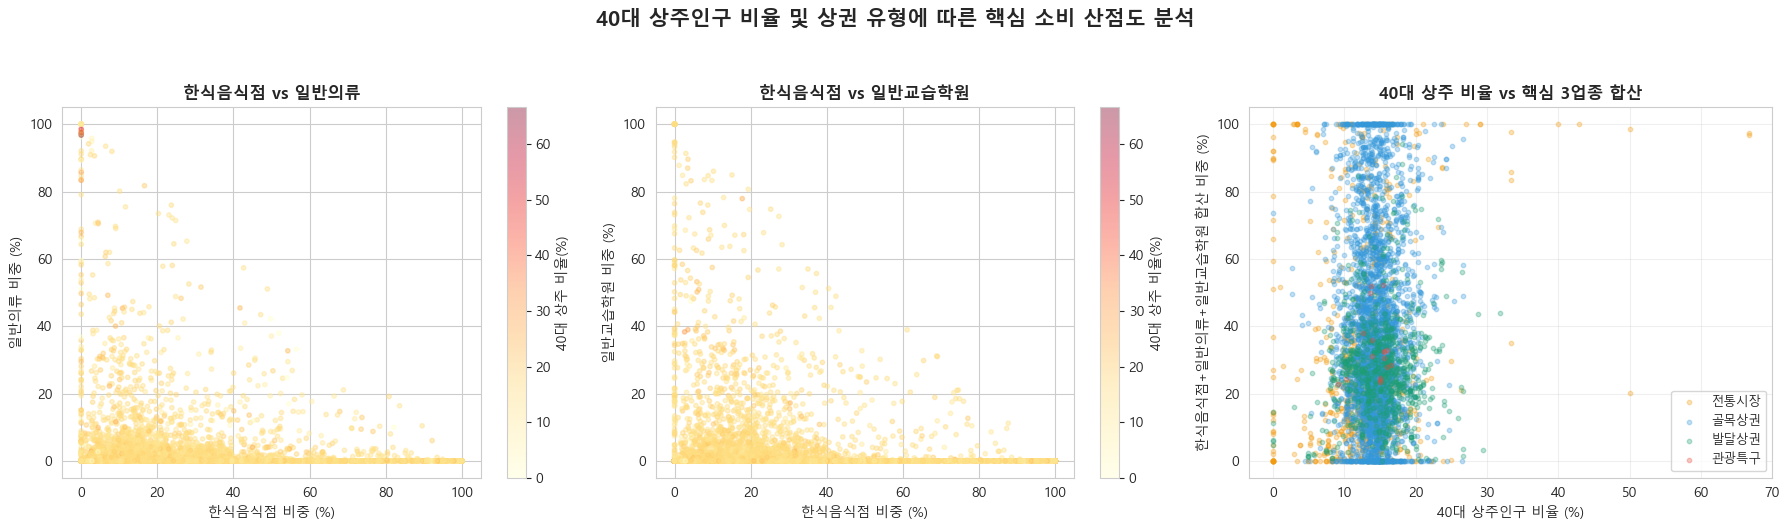

In [8]:
# %% 40대 산점도: 한식 vs 의류/학원 (40대 상주 비율 색상)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 너무 많은 점이 겹치는 것을 방지하기 위한 샘플링 (랜덤 시드 고정)
sample = merged_df_40.sample(n=min(5000, len(merged_df_40)), random_state=42)

# 가독성을 위해 컬럼명을 변수에 할당
col1 = f'{업종1}_비중' # 한식음식점_비중
col2 = f'{업종2}_비중' # 일반의류_비중
col3 = f'{업종3}_비중' # 일반교습학원_비중
 
# (1) 한식 vs 일반의류 (색상: 40대 상주 비율)
ax1 = axes[0]
sc = ax1.scatter(sample[col1], sample[col2],
                 c=sample['40대_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax1.set_xlabel(f'{업종1} 비중 (%)')
ax1.set_ylabel(f'{업종2} 비중 (%)')
ax1.set_title(f'{업종1} vs {업종2}', fontweight='bold')
plt.colorbar(sc, ax=ax1, label='40대 상주 비율(%)')
 
# (2) 한식 vs 일반교습학원 (색상: 40대 상주 비율)
ax2 = axes[1]
sc2 = ax2.scatter(sample[col1], sample[col3],
                  c=sample['40대_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax2.set_xlabel(f'{업종1} 비중 (%)')
ax2.set_ylabel(f'{업종3} 비중 (%)')
ax2.set_title(f'{업종1} vs {업종3}', fontweight='bold')
plt.colorbar(sc2, ax=ax2, label='40대 상주 비율(%)')
 
# (3) 40대 상주 비율 vs 3업종 합산 (상권 유형별 색상)
ax3 = axes[2]
색_map = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}

# 상권 구분이 존재하는 데이터만 추출하여 반복문 실행
상권_list_40 = sample['상권_구분_코드_명'].dropna().unique()

for 구분 in 상권_list_40:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    ax3.scatter(sub['40대_상주_비율'], sub['TOP3_합산_비중'],
                alpha=0.3, s=10, color=색_map.get(구분, 'gray'), label=구분)
    
ax3.set_xlabel('40대 상주인구 비율 (%)')
ax3.set_ylabel(f'{업종1}+{업종2}+{업종3} 합산 비중 (%)')
ax3.set_title('40대 상주 비율 vs 핵심 3업종 합산', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
 
plt.suptitle('40대 상주인구 비율 및 상권 유형에 따른 핵심 소비 산점도 분석', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

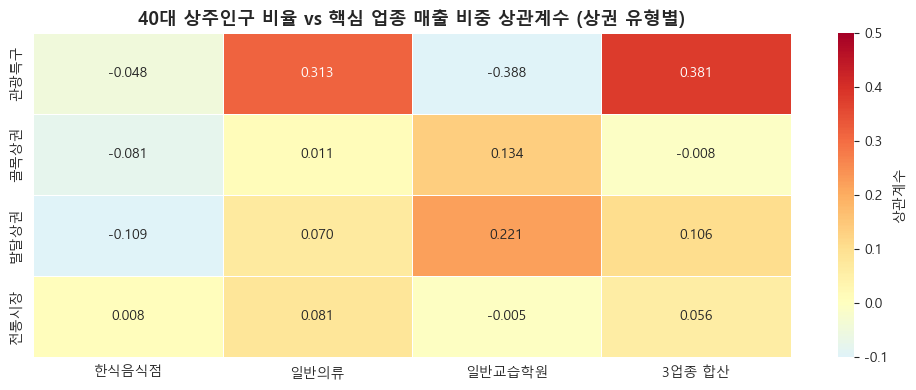

In [9]:
# %% 히트맵: 40대 상주 비율 vs 핵심 3업종 매출 비중
corr_data_40 = []

# 상권 구분이 존재하는 고유값 리스트 추출
상권_list_40 = merged_df_40['상권_구분_코드_명'].dropna().unique()

# 앞서 정의한 업종 변수들을 활용하여 반복문 대상 리스트 생성
col1 = f'{업종1}_비중' # 한식음식점_비중
col2 = f'{업종2}_비중' # 일반의류_비중
col3 = f'{업종3}_비중' # 일반교습학원_비중
target_cols = [col1, col2, col3, 'TOP3_합산_비중']

for 구분 in 상권_list_40:
    sub = merged_df_40[merged_df_40['상권_구분_코드_명'] == 구분]
    row = []
    
    # 핵심 3업종 및 합산 비중까지 4개 컬럼 순회
    for col in target_cols:
        # 데이터가 2개 이상 있어야 상관계수 계산 가능 (에러 방지)
        if len(sub) > 1:
            c = sub[['40대_상주_비율', col]].corr().iloc[0, 1]
        else:
            c = np.nan
        row.append(c)
        
    corr_data_40.append(row)
 
# 리스트를 데이터프레임으로 변환 (인덱스와 컬럼명 지정)
corr_df_40 = pd.DataFrame(corr_data_40, index=상권_list_40, columns=[업종1, 업종2, 업종3, '3업종 합산'])
 
# 시각화 그리기
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_df_40, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.1, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})

ax.set_title('40대 상주인구 비율 vs 핵심 업종 매출 비중 상관계수 (상권 유형별)', fontsize=13, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [10]:
# %% 40대 성별 분석 및 데이터 준비
# 1. 성별/업종별 매출 집계 (40대 타겟 업종: 한식, 의류, 학원)
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']
타겟_sales_40 = sales[sales['서비스_업종_코드_명'].isin(타겟3_40대)]

성별_타겟_40 = 타겟_sales_40.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
).agg(남성=('남성_매출_금액', 'sum'), 여성=('여성_매출_금액', 'sum'), 총=('당월_매출_금액', 'sum')).reset_index()

# 2. 40대 상주인구 비율 데이터와 병합 (df_상주 활용)
# (앞서 만든 40대_상주_비율 컬럼이 df_상주에 포함되어 있어야 합니다)
성별_타겟_40 = 성별_타겟_40.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '40대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 성별 매출 비율 계산
성별_타겟_40['여성비율'] = 성별_타겟_40['여성'] / 성별_타겟_40['총'].replace(0, np.nan) * 100
성별_타겟_40['남성비율'] = 성별_타겟_40['남성'] / 성별_타겟_40['총'].replace(0, np.nan) * 100

# 4. 40대 상주 비율 기준 3구간 분할
성별_타겟_40['40대_상주_구간'] = pd.qcut(
    성별_타겟_40['40대_상주_비율'].dropna(), q=3,
    labels=['40대 낮음', '40대 중간', '40대 높음'], duplicates='drop'
)

# 5. 결과 출력
print('📊 40대 상주 구간 × 업종 × 성별 매출 비율')
print(f'{"업종":<15} {"40대 구간":<12} {"여성매출비율":>12} {"남성매출비율":>12}') 
print('-' * 60) 

for 업종 in 타겟3_40대:
    for 구간 in ['40대 낮음', '40대 중간', '40대 높음']:
        # 해당 업종과 구간에 맞는 데이터 필터링
        sub = 성별_타겟_40[(성별_타겟_40['서비스_업종_코드_명'] == 업종) & (성별_타겟_40['40대_상주_구간'] == 구간)]
        
        # 평균 비중 산출
        여성_평균 = sub["여성비율"].mean()
        남성_평균 = sub["남성비율"].mean()
        
        # 여성과 남성 비율을 나란히 출력
        print(f'{업종:<15} {구간:<12} {여성_평균:>11.1f}% {남성_평균:>11.1f}%')

📊 40대 상주 구간 × 업종 × 성별 매출 비율
업종              40대 구간             여성매출비율       남성매출비율
------------------------------------------------------------
한식음식점           40대 낮음              31.4%        54.6%
한식음식점           40대 중간              32.1%        54.9%
한식음식점           40대 높음              30.5%        51.1%
일반의류            40대 낮음              71.0%        27.2%
일반의류            40대 중간              72.1%        26.3%
일반의류            40대 높음              70.0%        27.6%
일반교습학원          40대 낮음              55.9%        43.2%
일반교습학원          40대 중간              55.3%        44.1%
일반교습학원          40대 높음              55.6%        43.7%


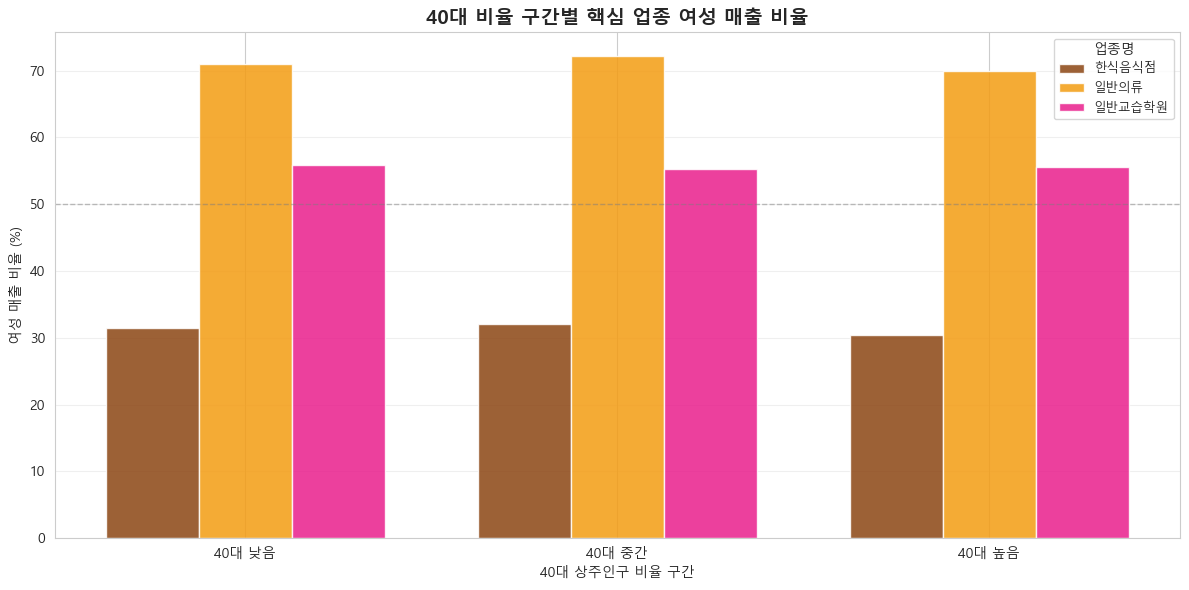

In [11]:
# %% 40대 상주 비율 구간별 업종 여성 매출 비율 시각화

# 1. 40대 여성 매출 비율 평균 집계
성별결과_40_여성 = 성별_타겟_40.groupby(['서비스_업종_코드_명', '40대_상주_구간'])['여성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(12, 6))

# 💡 40대 타겟 업종 적용 및 기존 색상 톤앤매너 유지
업종색 = {'한식음식점': '#8B4513', '일반의류': '#F39C12', '일반교습학원': '#E91E8C'}
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 
 
# 3. 업종별 막대 그래프 생성
for i, 업종 in enumerate(타겟3_40대):
    sub = 성별결과_40_여성[성별결과_40_여성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대를 나란히 배치
    ax.bar(x + i*w - w, sub['여성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['40대 낮음', '40대 중간', '40대 높음']) # 구간명 40대로 고정

ax.set_ylabel('여성 매출 비율 (%)')
ax.set_xlabel('40대 상주인구 비율 구간')
ax.set_title('40대 비율 구간별 핵심 업종 여성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선 (여성 주도 소비 판단 기준)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

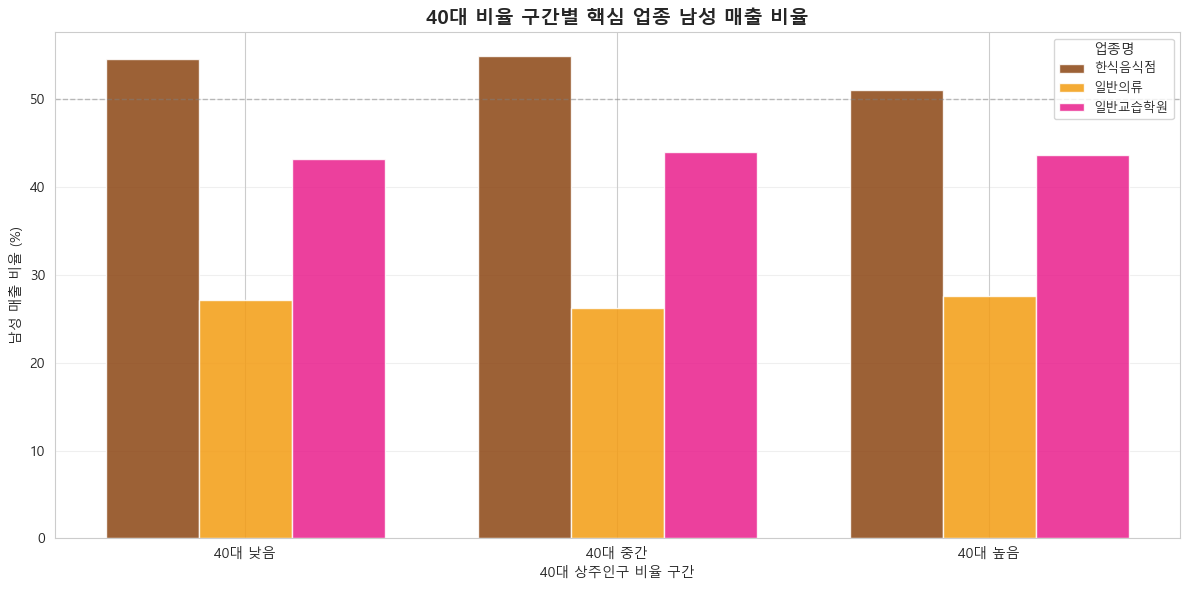

In [12]:
# %% 40대 상주 비율 구간별 업종 남성 매출 비율 시각화

# 1. 40대 남성 매출 데이터 집계 (성별_타겟_40 활용)
성별결과_40_남성 = 성별_타겟_40.groupby(['서비스_업종_코드_명', '40대_상주_구간'])['남성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(12, 6))

# 💡 여성 차트와 동일한 색상 매핑 (한식: 브라운, 의류: 오렌지, 학원: 핑크)
업종색 = {'한식음식점': '#8B4513', '일반의류': '#F39C12', '일반교습학원': '#E91E8C'}
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 # 막대 너비
 
# 3. 업종별 막대 그래프 생성 (남성비율 기준)
for i, 업종 in enumerate(타겟3_40대):
    sub = 성별결과_40_남성[성별결과_40_남성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대가 겹치지 않도록 배치
    ax.bar(x + i*w - w, sub['남성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['40대 낮음', '40대 중간', '40대 높음']) # 구간명 40대로 고정

ax.set_ylabel('남성 매출 비율 (%)')
ax.set_xlabel('40대 상주인구 비율 구간')
ax.set_title('40대 비율 구간별 핵심 업종 남성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선 (이 선을 넘으면 남성 소비가 주도적임을 의미)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# %% 40대 시간대 분석
# 1. 40대 타겟 업종 데이터 필터링 및 시간대별 매출 집계
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']
시간_매출_cols = [c for c in sales.columns if '시간대' in c and '매출_금액' in c] # 시간대 컬럼 자동 추출

시간_타겟_40 = sales[sales['서비스_업종_코드_명'].isin(타겟3_40대)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[시간_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 40대 상주인구 비율 데이터와 병합 (df_상주 활용)
시간_타겟_40 = 시간_타겟_40.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '40대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 40대 상주 비율 기준 3구간 분할
시간_타겟_40['40대_상주_구간'] = pd.qcut(
    시간_타겟_40['40대_상주_비율'].dropna(), q=3,
    labels=['40대 낮음', '40대 중간', '40대 높음'], duplicates='drop'
)

# 시간대 라벨 설정 (출력용)
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']

# 4. 결과 출력
print('\n📊 40대 상주 구간 × 업종 × 시간대 매출 비중')
for 업종 in 타겟3_40대:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 시간라벨:
        print(f' {l:>7}', end='')
    print()
    
    for 구간 in ['40대 낮음', '40대 중간', '40대 높음']:
        sub = 시간_타겟_40[(시간_타겟_40['서비스_업종_코드_명'] == 업종) & (시간_타겟_40['40대_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 시간_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>6.1f}%', end='')
        print()


📊 40대 상주 구간 × 업종 × 시간대 매출 비중

▸ 한식음식점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  40대 낮음          2.4%    2.5%   28.7%   11.6%   41.4%   13.4%
  40대 중간          2.4%    2.3%   27.4%   11.5%   42.4%   14.1%
  40대 높음          2.5%    2.0%   30.9%   10.5%   40.2%   14.0%

▸ 일반의류
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  40대 낮음          0.3%    4.1%   24.3%   38.9%   30.1%    2.4%
  40대 중간          0.2%    3.3%   22.6%   39.2%   32.4%    2.2%
  40대 높음          0.3%    3.3%   22.7%   38.9%   32.4%    2.4%

▸ 일반교습학원
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  40대 낮음          0.4%    6.9%   12.0%   31.5%   42.1%    7.1%
  40대 중간          0.3%    4.7%   11.4%   32.8%   43.8%    7.0%
  40대 높음          0.4%    5.9%   12.9%   31.7%   41.6%    7.5%


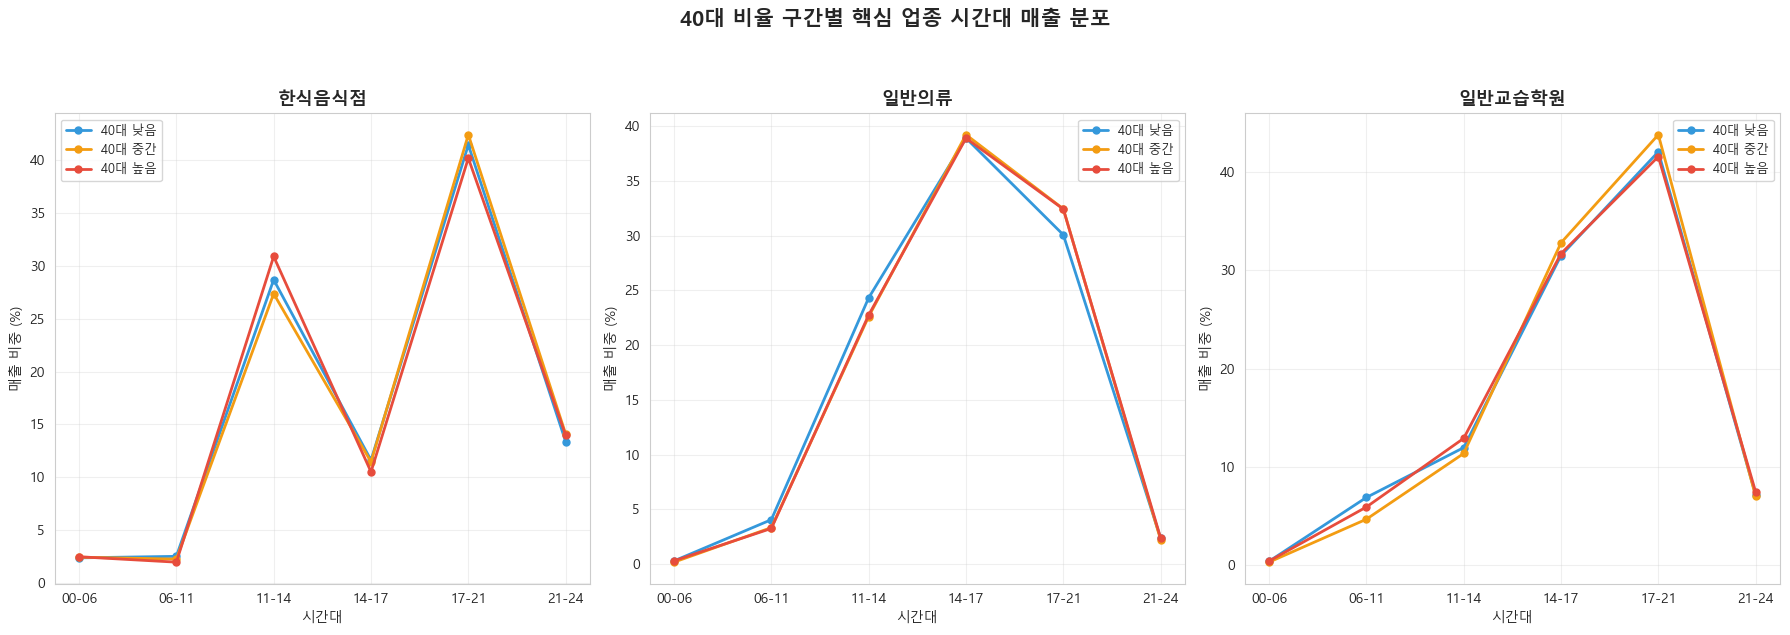

In [17]:
# %% 40대 상주 비율 구간별 업종 시간대 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 💡 분석 대상 업종 정의 (40대 타겟으로 변경)
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']

for idx, 업종 in enumerate(타겟3_40대):
    ax = axes[idx]
    # 이전 분석과 동일한 색상 팔레트 유지하여 대시보드 통일감 확보
    구간색 = {'40대 낮음': '#3498DB', '40대 중간': '#F39C12', '40대 높음': '#E74C3C'}

    for 구간 in ['40대 낮음', '40대 중간', '40대 높음']:
        # 해당 업종과 40대 구간 필터링
        sub = 시간_타겟_40[(시간_타겟_40['서비스_업종_코드_명'] == 업종) & 
                           (시간_타겟_40['40대_상주_구간'] == 구간)]
        
        # 시간대별 매출 비중 평균 계산
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 시간_매출_cols]
        
        # 꺾은선 그래프 그리기
        ax.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)

    # 개별 차트 디테일 설정
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_xlabel('시간대')
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# 전체 타이틀 및 레이아웃 조정
fig.suptitle('40대 비율 구간별 핵심 업종 시간대 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [15]:
# %% 40대 요일 분석
# 1. 40대 타겟 업종 데이터 필터링 및 요일별 매출 집계
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']
요일_매출_cols = [c for c in sales.columns if '요일' in c and '매출_금액' in c] # 요일 컬럼 자동 추출

요일_타겟_40 = sales[sales['서비스_업종_코드_명'].isin(타겟3_40대)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[요일_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 40대 상주인구 비율 데이터와 병합 (df_상주 활용)
요일_타겟_40 = 요일_타겟_40.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '40대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 40대 상주 비율 기준 3구간 분할
요일_타겟_40['40대_상주_구간'] = pd.qcut(
    요일_타겟_40['40대_상주_비율'].dropna(), q=3,
    labels=['40대 낮음', '40대 중간', '40대 높음'], duplicates='drop'
)

# 요일 라벨 설정 (출력용)
요일라벨 = ['월', '화', '수', '목', '금', '토', '일']

# 4. 결과 출력
print('\n📊 40대 상주 구간 × 업종 × 요일 매출 비중')
for 업종 in 타겟3_40대:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 요일라벨:
        print(f' {l:>6}', end='')
    print()
    
    for 구간 in ['40대 낮음', '40대 중간', '40대 높음']:
        sub = 요일_타겟_40[(요일_타겟_40['서비스_업종_코드_명'] == 업종) & (요일_타겟_40['40대_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 요일_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>5.1f}%', end='')
        print()


📊 40대 상주 구간 × 업종 × 요일 매출 비중

▸ 한식음식점
  구간                월      화      수      목      금      토      일
  40대 낮음        13.1%  14.2%  14.5%  14.7%  16.3%  15.7%  11.5%
  40대 중간        12.9%  13.9%  14.3%  14.4%  16.1%  16.3%  12.1%
  40대 높음        13.4%  14.5%  14.9%  15.2%  16.4%  14.9%  10.7%

▸ 일반의류
  구간                월      화      수      목      금      토      일
  40대 낮음        13.9%  14.7%  15.1%  15.4%  15.9%  15.7%   9.3%
  40대 중간        13.8%  15.0%  15.6%  15.4%  15.9%  15.8%   8.5%
  40대 높음        13.6%  15.1%  15.6%  15.8%  16.4%  15.5%   8.0%

▸ 일반교습학원
  구간                월      화      수      목      금      토      일
  40대 낮음        20.0%  18.5%  17.5%  16.3%  16.3%   7.8%   3.7%
  40대 중간        20.4%  18.8%  17.5%  15.9%  16.5%   7.4%   3.5%
  40대 높음        19.5%  18.1%  16.8%  16.1%  16.1%   8.9%   4.5%


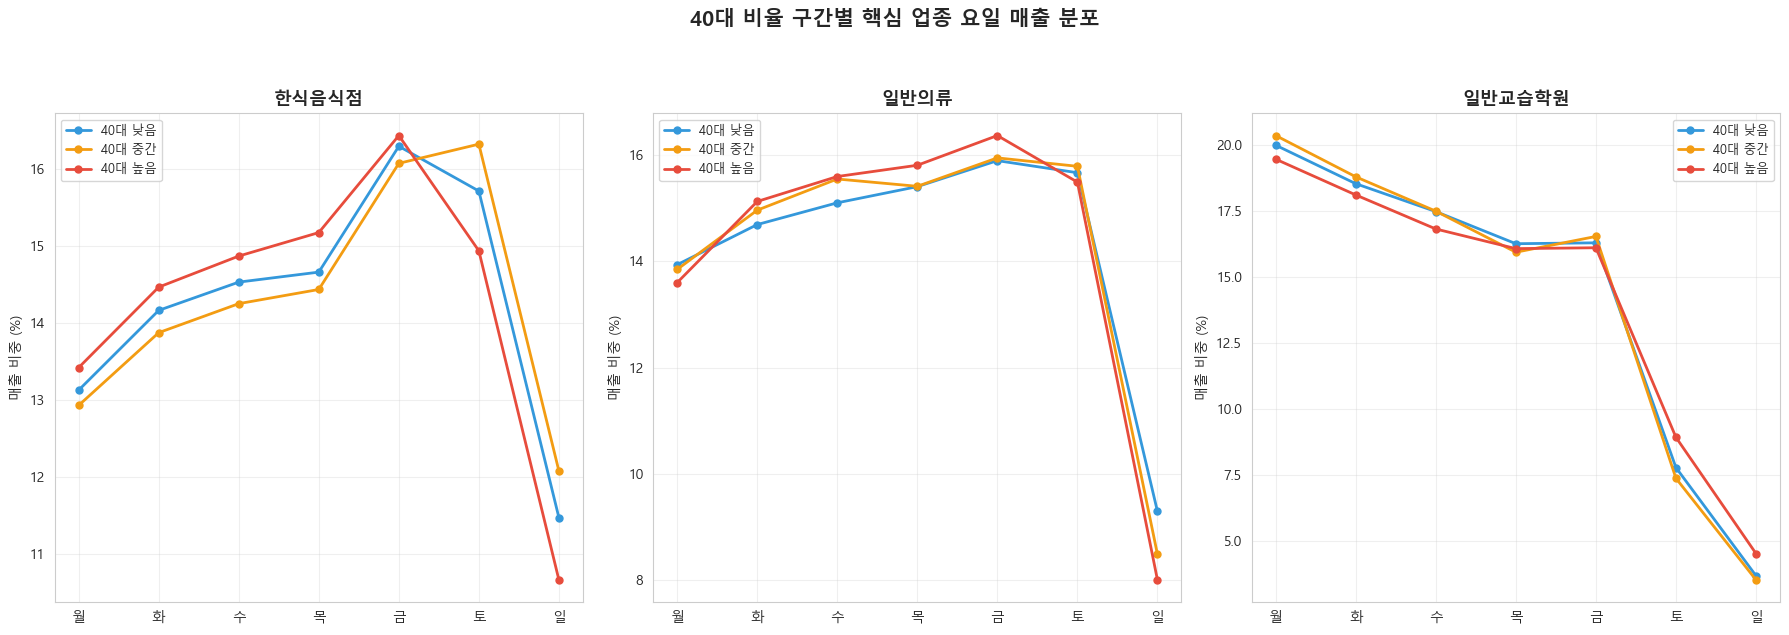

In [18]:
# %% 40대 상주 비율 구간별 업종 요일 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 💡 분석 대상 40대 타겟 업종
타겟3_40대 = ['한식음식점', '일반의류', '일반교습학원']
 
for idx, 업종 in enumerate(타겟3_40대):
    ax = axes[idx]
    # 이전 분석과 동일한 색상 팔레트 유지 (밀집도: 파랑 -> 주황 -> 빨강)
    구간색 = {'40대 낮음': '#3498DB', '40대 중간': '#F39C12', '40대 높음': '#E74C3C'}
 
    for 구간 in ['40대 낮음', '40대 중간', '40대 높음']:
        # 해당 업종과 40대 구간 필터링
        sub = 요일_타겟_40[(요일_타겟_40['서비스_업종_코드_명'] == 업종) & 
                           (요일_타겟_40['40대_상주_구간'] == 구간)]
        
        # 요일별 매출 비중 평균 계산 (요일_매출_cols 활용)
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 요일_매출_cols]
        
        # 꺾은선 그래프 생성
        ax.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)
 
    # 차트 개별 설정
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
# 전체 제목 및 레이아웃 정리
fig.suptitle('40대 비율 구간별 핵심 업종 요일 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 10대 데이터확인

In [19]:
# %% [Step 0] 10대 타겟 선정을 위한 업종별 매출 순위 확인

# 💡 추정매출 데이터에 있는 10대 매출 금액 컬럼을 사용합니다.
기준_컬럼_10대 = '연령대_10_매출_금액' 

if 기준_컬럼_10대 in sales.columns:
    print(f'✅ "{기준_컬럼_10대}" 기준으로 10대 매출 순위를 집계합니다.\n')
    
    # 1. 10대 매출액 기준으로 업종별 집계 및 정렬
    업종별_순위_10대 = sales.groupby('서비스_업종_코드_명')[기준_컬럼_10대].sum().reset_index()
    업종별_순위_10대 = 업종별_순위_10대.sort_values(by=기준_컬럼_10대, ascending=False).reset_index(drop=True)
    
    # 2. 비중 계산
    총매출_10대 = 업종별_순위_10대[기준_컬럼_10대].sum()
    업종별_순위_10대['매출비중(%)'] = (업종별_순위_10대[기준_컬럼_10대] / 총매출_10대) * 100
    
    # 3. Top 15 출력
    print('🏆 서울시 10대 매출 집중 업종 Top 15')
    print('-' * 60)
    print(f'{"순위":<4} {"업종명":<15} {"10대 총매출액(원)":>18} {"비중(%)":>8}')
    print('-' * 60)
    
    for i in range(15):
        이름 = 업종별_순위_10대.loc[i, "서비스_업종_코드_명"]
        매출 = 업종별_순위_10대.loc[i, 기준_컬럼_10대]
        비중 = 업종별_순위_10대.loc[i, "매출비중(%)"]
        print(f'{i+1:<4} {이름:<15} {매출:>21,.0f} {비중:>7.1f}%')

else:
    print(f'❌ 데이터에 {기준_컬럼_10대} 컬럼이 없습니다. sales.columns를 확인해 주세요.')

✅ "연령대_10_매출_금액" 기준으로 10대 매출 순위를 집계합니다.

🏆 서울시 10대 매출 집중 업종 Top 15
------------------------------------------------------------
순위   업종명                    10대 총매출액(원)    비중(%)
------------------------------------------------------------
1    한식음식점                 322,789,592,249    13.4%
2    편의점                   265,792,109,494    11.0%
3    일반의류                  234,267,144,267     9.7%
4    커피-음료                 212,919,844,712     8.8%
5    호프-간이주점               164,870,333,338     6.8%
6    분식전문점                 101,189,109,092     4.2%
7    슈퍼마켓                   86,569,562,486     3.6%
8    PC방                    86,460,022,825     3.6%
9    일반의원                   77,832,698,078     3.2%
10   화장품                    69,672,496,747     2.9%
11   양식음식점                  69,580,867,987     2.9%
12   패스트푸드점                 62,450,555,591     2.6%
13   일식음식점                  51,068,598,591     2.1%
14   컴퓨터및주변장치판매             49,240,229,689     2.0%
15   의약품                    47,891

In [20]:
# %% 10대 상주인구 기반 상권 유형별 상관계수 분석 통합 코드

# 1. 10대 상주인구 비율 생성
df_상주['10대_상주_비율'] = df_상주['연령대_10_상주인구_수'].fillna(0) / df_상주['총_상주인구_수'].replace(0, np.nan) * 100

# 2. 상권별 당월 총매출 집계
총매출_df = sales.groupby(['기준_년분기_코드', '상권_코드'])['당월_매출_금액'].sum().reset_index(name='상권_총매출')

# 3. 💡 데이터 기반 10대 Top 3 업종 적용! 
# (원하신다면 '분식전문점', 'PC방' 등으로 언제든 교체 가능합니다)
타겟3_10대 = ['한식음식점', '편의점', '일반의류'] 
타겟_매출 = sales[sales['서비스_업종_코드_명'].isin(타겟3_10대)]
타겟_피벗 = 타겟_매출.groupby(['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명'])['당월_매출_금액'].sum().unstack(fill_value=0).reset_index()

# 4. 데이터 병합 및 비중 계산
merged_df_10 = 총매출_df.merge(타겟_피벗, on=['기준_년분기_코드', '상권_코드'], how='left').fillna(0)
merged_df_10 = merged_df_10.merge(df_상주[['기준_년분기_코드', '상권_코드', '10대_상주_비율']], on=['기준_년분기_코드', '상권_코드'], how='inner')

# 파생변수: 개별 업종 비중 및 TOP3 합산 비중
업종1, 업종2, 업종3 = 타겟3_10대[0], 타겟3_10대[1], 타겟3_10대[2]

merged_df_10[f'{업종1}_비중'] = merged_df_10[업종1] / merged_df_10['상권_총매출'].replace(0, np.nan) * 100
merged_df_10[f'{업종2}_비중'] = merged_df_10[업종2] / merged_df_10['상권_총매출'].replace(0, np.nan) * 100
merged_df_10[f'{업종3}_비중'] = merged_df_10[업종3] / merged_df_10['상권_총매출'].replace(0, np.nan) * 100
merged_df_10['TOP3_합산_비중'] = merged_df_10[f'{업종1}_비중'] + merged_df_10[f'{업종2}_비중'] + merged_df_10[f'{업종3}_비중']

# 5. [에러방지] 상권_구분_코드_명 추가 병합
if '상권_구분_코드_명' not in merged_df_10.columns:
    merged_df_10 = merged_df_10.merge(
        df_상주[['상권_코드', '상권_구분_코드_명']].drop_duplicates(),
        on='상권_코드', 
        how='left'
    )

# 6. 상주인구 5구간 분할 (시각화용)
merged_df_10['10대_상주_5구간'] = pd.qcut(merged_df_10['10대_상주_비율'].dropna(), q=5, 
                               labels=['하위 20%', '20~40%', '40~60%', '60~80%', '상위 20%'], duplicates='drop')

# 7. '상권' 변수 고유 리스트 재정의
상권_리스트 = merged_df_10['상권_구분_코드_명'].dropna().unique()

# 8. 최종 텍스트 표 출력
print('\n📊 상권구분별 10대 상주인구 비율 vs 10대 Top3 업종(한식·편의점·의류)')
print('-' * 95)
print(f'{"유형":<10} {"10대비율":>8} {업종1:>10} {업종2:>10} {업종3:>10} {"3업종합":>8} {"상관계수":>10}')
print('-' * 95)

for 구분 in 상권_리스트:
    sub = merged_df_10[merged_df_10['상권_구분_코드_명'] == 구분]
    
    if not sub.empty and len(sub) > 1:
        corr = sub[['10대_상주_비율', 'TOP3_합산_비중']].corr().iloc[0, 1]
        
        print(f'{구분:<10} {sub["10대_상주_비율"].mean():>7.1f}%'
              f' {sub[f"{업종1}_비중"].mean():>9.1f}%'
              f' {sub[f"{업종2}_비중"].mean():>9.1f}%'
              f' {sub[f"{업종3}_비중"].mean():>9.1f}%'
              f' {sub["TOP3_합산_비중"].mean():>7.1f}%'
              f' {corr:>9.3f}')
    else:
        print(f'{구분:<10} 데이터 부족으로 분석 제외')


📊 상권구분별 10대 상주인구 비율 vs 10대 Top3 업종(한식·편의점·의류)
-----------------------------------------------------------------------------------------------
유형            10대비율      한식음식점        편의점       일반의류     3업종합       상관계수
-----------------------------------------------------------------------------------------------
관광특구           6.1%      12.3%       4.2%      24.2%    40.7%     0.340
골목상권          10.1%      29.8%       7.0%       3.0%    39.8%    -0.170
발달상권           8.9%      19.5%       5.3%       5.1%    29.8%    -0.227
전통시장           7.2%      22.2%       0.8%       7.3%    30.3%    -0.016


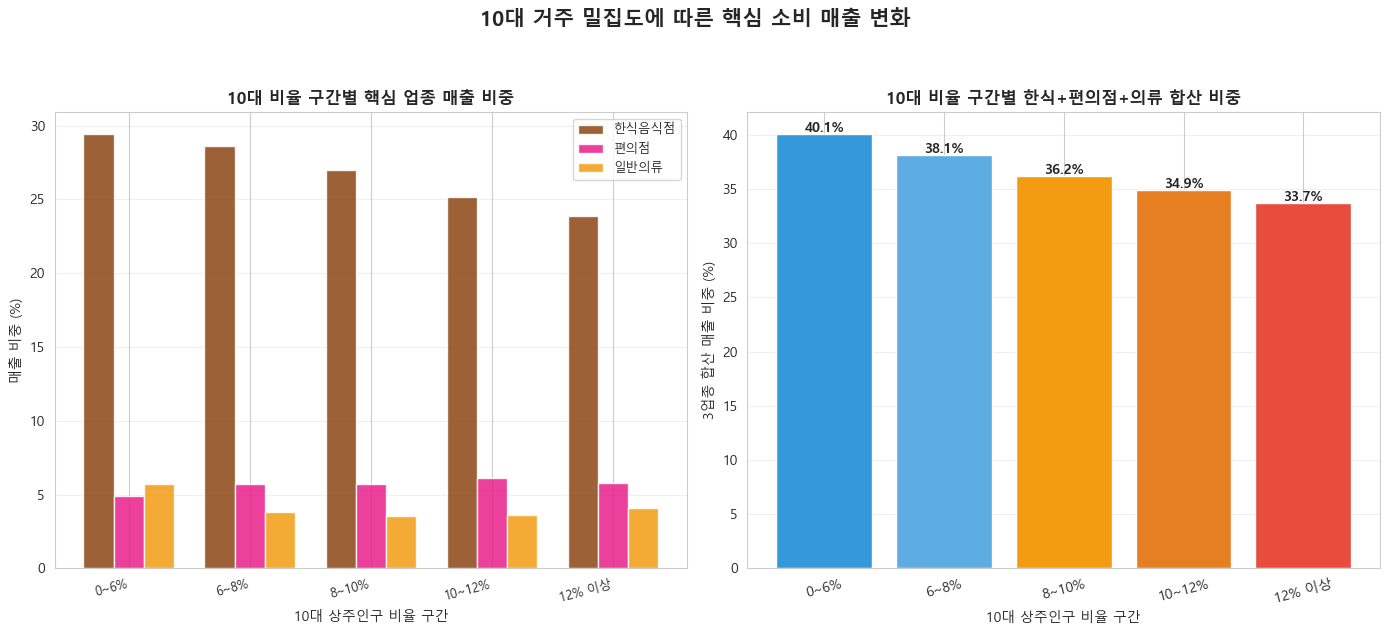

In [23]:
# %% 10대 상주 비율 5분위별 분석 및 시각화 (색상 동기화 버전)

# 1. 10대 상주 비율 5분위 구간 나누기 (실제 경곗값 bins 추출)
merged_df_10['10대_구간'], bins = pd.qcut(
    merged_df_10['10대_상주_비율'].dropna(), q=5, retbins=True, duplicates='drop'
)

# 2. 직관적인 구간 라벨 자동 생성
라벨 = [f'{bins[i]:.0f}~{bins[i+1]:.0f}%' for i in range(len(bins)-2)]
라벨.append(f'{bins[-2]:.0f}% 이상')

merged_df_10['10대_구간'] = pd.qcut(
    merged_df_10['10대_상주_비율'].dropna(), q=5, labels=라벨, duplicates='drop'
)
 
# 3. 구간별 평균 집계 (10대 타겟 업종)
구간별_10 = merged_df_10.groupby('10대_구간').agg(
    평균10대=('10대_상주_비율', 'mean'),
    한식=('한식음식점_비중', 'mean'),
    편의점=('편의점_비중', 'mean'),
    의류=('일반의류_비중', 'mean'),
    합계=('TOP3_합산_비중', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

# ==========================================
# 4. 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 업종별 분리 (좌측 차트)
ax1 = axes[0]
x = np.arange(len(구간별_10))
w = 0.25

# 💡 10대 타겟 업종 색상 적용 (한식: 브라운, 편의점: 핑크, 의류: 오렌지)
ax1.bar(x - w, 구간별_10['한식'], w, color='#8B4513', alpha=0.85, label='한식음식점')
ax1.bar(x, 구간별_10['편의점'], w, color='#E91E8C', alpha=0.85, label='편의점')
ax1.bar(x + w, 구간별_10['의류'], w, color='#F39C12', alpha=0.85, label='일반의류')

ax1.set_xticks(x)
ax1.set_xticklabels(구간별_10['10대_구간'], fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_xlabel('10대 상주인구 비율 구간')
ax1.set_title('10대 비율 구간별 핵심 업종 매출 비중', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
 
# (2) 3업종 합산 (우측 차트)
ax2 = axes[1]
# 💡 그라데이션 색상 적용
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax2.bar(구간별_10['10대_구간'], 구간별_10['합계'], color=colors, edgecolor='white')

ax2.set_ylabel('3업종 합산 매출 비중 (%)')
ax2.set_xlabel('10대 상주인구 비율 구간')
ax2.set_title('10대 비율 구간별 한식+편의점+의류 합산 비중', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)
 
# 막대 위 수치 텍스트 표시
for bar, val in zip(bars, 구간별_10['합계']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
plt.suptitle('10대 거주 밀집도에 따른 핵심 소비 매출 변화', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [21]:
# %% 10대 핵심 3업종 간 상관관계 + 상권 유형 비교

# 1. 3업종 간 상관관계 분석
corr_3_10 = merged_df_10[['한식음식점_비중', '편의점_비중', '일반의류_비중']].corr()
 
print('📊 10대 핵심 3업종 간 상관관계')
print(corr_3_10.round(3))
 
# 2. 업종별 비중 상위 20% 상권 데이터 추출
한식_상위_10 = merged_df_10[merged_df_10['한식음식점_비중'] > merged_df_10['한식음식점_비중'].quantile(0.8)]
편의점_상위_10 = merged_df_10[merged_df_10['편의점_비중'] > merged_df_10['편의점_비중'].quantile(0.8)]
의류_상위_10 = merged_df_10[merged_df_10['일반의류_비중'] > merged_df_10['일반의류_비중'].quantile(0.8)]
 
# 3. 상위 상권 프로필 비교 출력
print('\n📊 10대 타겟 업종별 상위 20% 상권 프로필 비교')
print(f'{"":>12} {"10대비율":>8} {"한식":>8} {"편의점":>8} {"의류":>8} {"상권구성":>30}')
print('-' * 85)

for name, df in [('한식 상위', 한식_상위_10), ('편의점 상위', 편의점_상위_10), ('의류 상위', 의류_상위_10)]:
    # 상권 구분(골목, 발달, 전통시장 등) 비율 추출
    구성 = df['상권_구분_코드_명'].value_counts(normalize=True).head(3)
    구성str = ', '.join([f'{k} {v*100:.0f}%' for k, v in 구성.items()])
    
    # 간격에 맞추어 10대 전용 데이터 출력
    print(f'{name:>12} {df["10대_상주_비율"].mean():>7.1f}%'
          f' {df["한식음식점_비중"].mean():>7.1f}%'
          f' {df["편의점_비중"].mean():>7.1f}%'
          f' {df["일반의류_비중"].mean():>7.1f}%'
          f' {구성str:>30}')

📊 10대 핵심 3업종 간 상관관계
          한식음식점_비중  편의점_비중  일반의류_비중
한식음식점_비중      1.00   -0.10    -0.16
편의점_비중       -0.10    1.00    -0.07
일반의류_비중      -0.16   -0.07     1.00

📊 10대 타겟 업종별 상위 20% 상권 프로필 비교
                10대비율       한식      편의점       의류                           상권구성
-------------------------------------------------------------------------------------
       한식 상위     8.9%    69.7%     2.7%     1.7%    골목상권 82%, 전통시장 14%, 발달상권 4%
      편의점 상위     9.5%    23.5%    22.8%     2.5%    골목상권 86%, 발달상권 12%, 전통시장 2%
       의류 상위     8.7%    20.0%     4.7%    18.8%   골목상권 48%, 전통시장 26%, 발달상권 24%


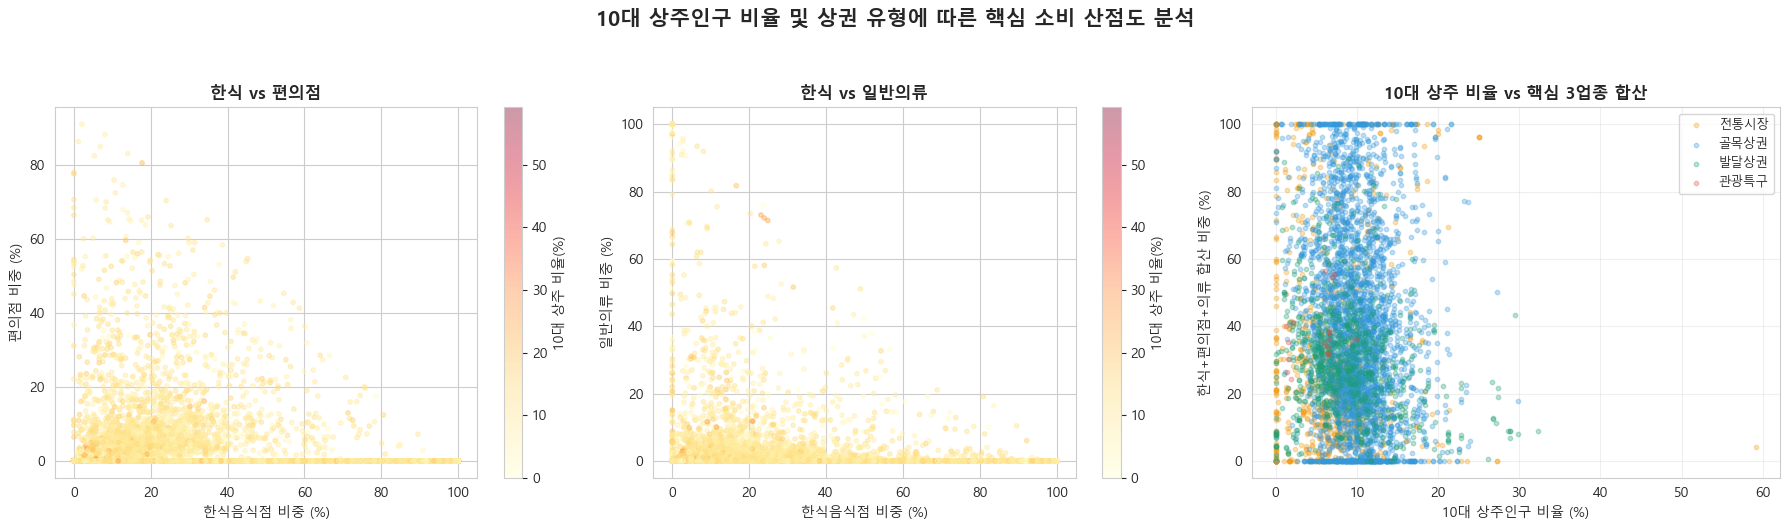

In [24]:
# %% 10대 산점도: 한식 vs 편의점/의류 (10대 상주 비율 색상)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 너무 많은 점이 겹치는 것을 방지하기 위한 샘플링 (랜덤 시드 고정)
sample_10 = merged_df_10.sample(n=min(5000, len(merged_df_10)), random_state=42)

# 가독성을 위해 컬럼명 변수화
col1, col2, col3 = '한식음식점_비중', '편의점_비중', '일반의류_비중'

# (1) 한식 vs 편의점 (색상: 10대 상주 비율)
ax1 = axes[0]
sc1 = ax1.scatter(sample_10[col1], sample_10[col2],
                  c=sample_10['10대_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax1.set_xlabel('한식음식점 비중 (%)')
ax1.set_ylabel('편의점 비중 (%)')
ax1.set_title('한식 vs 편의점', fontweight='bold')
plt.colorbar(sc1, ax=ax1, label='10대 상주 비율(%)')

# (2) 한식 vs 일반의류 (색상: 10대 상주 비율)
ax2 = axes[1]
sc2 = ax2.scatter(sample_10[col1], sample_10[col3],
                  c=sample_10['10대_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax2.set_xlabel('한식음식점 비중 (%)')
ax2.set_ylabel('일반의류 비중 (%)')
ax2.set_title('한식 vs 일반의류', fontweight='bold')
plt.colorbar(sc2, ax=ax2, label='10대 상주 비율(%)')

# (3) 10대 상주 비율 vs 3업종 합산 (상권 유형별 색상)
ax3 = axes[2]
색_map = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}

# 상권 구분이 존재하는 데이터만 추출하여 반복문 실행
상권_list_10 = sample_10['상권_구분_코드_명'].dropna().unique()

for 구분 in 상권_list_10:
    sub = sample_10[sample_10['상권_구분_코드_명'] == 구분]
    ax3.scatter(sub['10대_상주_비율'], sub['TOP3_합산_비중'],
                alpha=0.3, s=10, color=색_map.get(구분, 'gray'), label=구분)
    
ax3.set_xlabel('10대 상주인구 비율 (%)')
ax3.set_ylabel('한식+편의점+의류 합산 비중 (%)')
ax3.set_title('10대 상주 비율 vs 핵심 3업종 합산', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.suptitle('10대 상주인구 비율 및 상권 유형에 따른 핵심 소비 산점도 분석', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

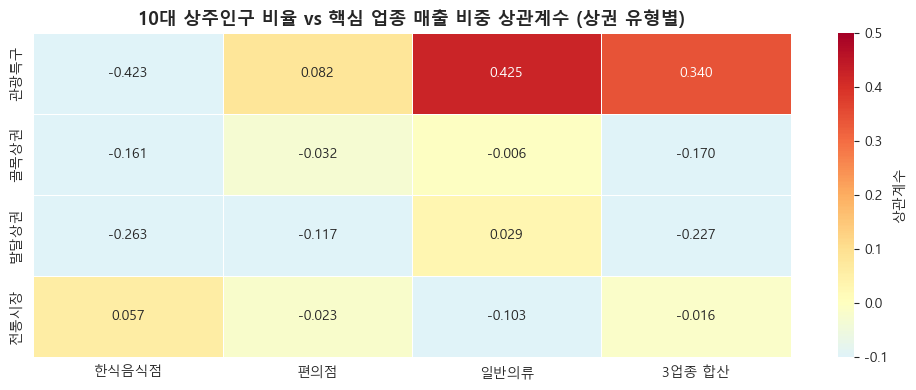

In [22]:
# %% 히트맵: 10대 상주 비율 vs 핵심 3업종 매출 비중
corr_data_10 = []

# 상권 구분이 존재하는 고유값 리스트 추출
상권_list_10 = merged_df_10['상권_구분_코드_명'].dropna().unique()

# 10대 핵심 3업종 컬럼 리스트
target_cols_10 = ['한식음식점_비중', '편의점_비중', '일반의류_비중', 'TOP3_합산_비중']

for 구분 in 상권_list_10:
    sub = merged_df_10[merged_df_10['상권_구분_코드_명'] == 구분]
    row = []
    
    # 핵심 3업종 및 합산 비중까지 4개 컬럼 순회
    for col in target_cols_10:
        # 데이터가 2개 이상 있어야 상관계수 계산 가능 (에러 방지)
        if len(sub) > 1:
            c = sub[['10대_상주_비율', col]].corr().iloc[0, 1]
        else:
            c = np.nan
        row.append(c)
        
    corr_data_10.append(row)
 
# 리스트를 데이터프레임으로 변환 (인덱스와 컬럼명 지정)
corr_df_10 = pd.DataFrame(corr_data_10, index=상권_list_10, columns=['한식음식점', '편의점', '일반의류', '3업종 합산'])
 
# 시각화 그리기
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_df_10, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.1, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})

ax.set_title('10대 상주인구 비율 vs 핵심 업종 매출 비중 상관계수 (상권 유형별)', fontsize=13, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [25]:
# %% 10대 성별 분석 및 데이터 준비

# 1. 성별/업종별 매출 집계 (10대 타겟 업종: 한식, 편의점, 의류)
타겟3_10대 = ['한식음식점', '편의점', '일반의류']
타겟_sales_10 = sales[sales['서비스_업종_코드_명'].isin(타겟3_10대)]

성별_타겟_10 = 타겟_sales_10.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
).agg(남성=('남성_매출_금액', 'sum'), 여성=('여성_매출_금액', 'sum'), 총=('당월_매출_금액', 'sum')).reset_index()

# 2. 10대 상주인구 비율 데이터와 병합 (df_상주 활용)
성별_타겟_10 = 성별_타겟_10.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '10대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 성별 매출 비율 계산
성별_타겟_10['여성비율'] = 성별_타겟_10['여성'] / 성별_타겟_10['총'].replace(0, np.nan) * 100
성별_타겟_10['남성비율'] = 성별_타겟_10['남성'] / 성별_타겟_10['총'].replace(0, np.nan) * 100

# 4. 10대 상주 비율 기준 3구간 분할
성별_타겟_10['10대_상주_구간'] = pd.qcut(
    성별_타겟_10['10대_상주_비율'].dropna(), q=3,
    labels=['10대 낮음', '10대 중간', '10대 높음'], duplicates='drop'
)

# 5. 결과 출력
print('📊 10대 상주 구간 × 업종 × 성별 매출 비율')
print(f'{"업종":<15} {"10대 구간":<12} {"여성매출비율":>12} {"남성매출비율":>12}') 
print('-' * 60) 

for 업종 in 타겟3_10대:
    for 구간 in ['10대 낮음', '10대 중간', '10대 높음']:
        # 해당 업종과 구간에 맞는 데이터 필터링
        sub = 성별_타겟_10[(성별_타겟_10['서비스_업종_코드_명'] == 업종) & (성별_타겟_10['10대_상주_구간'] == 구간)]
        
        # 평균 비중 산출
        여성_평균 = sub["여성비율"].mean()
        남성_평균 = sub["남성비율"].mean()
        
        # 여성과 남성 비율을 나란히 출력
        print(f'{업종:<15} {구간:<12} {여성_평균:>11.1f}% {남성_평균:>11.1f}%')

📊 10대 상주 구간 × 업종 × 성별 매출 비율
업종              10대 구간             여성매출비율       남성매출비율
------------------------------------------------------------
한식음식점           10대 낮음              31.0%        53.7%
한식음식점           10대 중간              32.0%        54.2%
한식음식점           10대 높음              31.1%        52.8%
편의점             10대 낮음              36.1%        62.1%
편의점             10대 중간              34.6%        63.9%
편의점             10대 높음              34.6%        63.6%
일반의류            10대 낮음              69.5%        28.3%
일반의류            10대 중간              71.4%        26.9%
일반의류            10대 높음              72.2%        25.8%


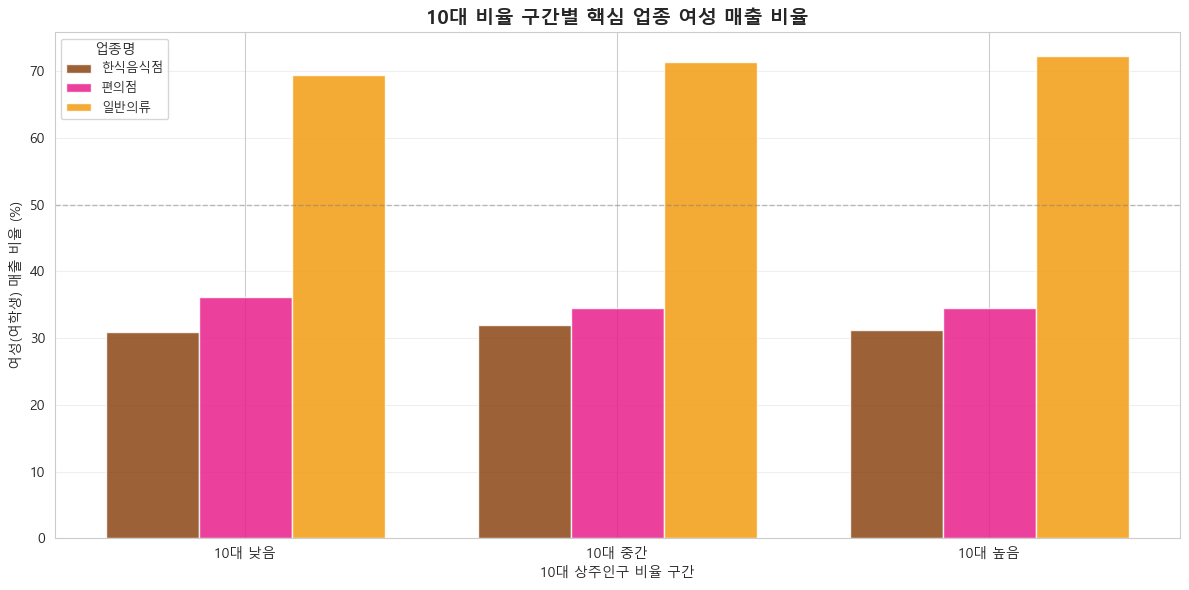

In [26]:
# %% 10대 상주 비율 구간별 업종 여성 매출 비율 시각화

# 1. 10대 여성 매출 비율 평균 집계 (성별_타겟_10 활용)
성별결과_10_여성 = 성별_타겟_10.groupby(['서비스_업종_코드_명', '10대_상주_구간'])['여성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(12, 6))

# 💡 10대 타겟 업종 적용 및 기존 색상 톤앤매너 유지 (한식: 브라운, 편의점: 핑크, 의류: 오렌지)
업종색 = {'한식음식점': '#8B4513', '편의점': '#E91E8C', '일반의류': '#F39C12'}
타겟3_10대 = ['한식음식점', '편의점', '일반의류']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 
 
# 3. 업종별 막대 그래프 생성
for i, 업종 in enumerate(타겟3_10대):
    sub = 성별결과_10_여성[성별결과_10_여성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대를 나란히 배치
    ax.bar(x + i*w - w, sub['여성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['10대 낮음', '10대 중간', '10대 높음']) # 구간명 10대로 고정

ax.set_ylabel('여성(여학생) 매출 비율 (%)')
ax.set_xlabel('10대 상주인구 비율 구간')
ax.set_title('10대 비율 구간별 핵심 업종 여성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선 (여성 주도 소비 판단 기준)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

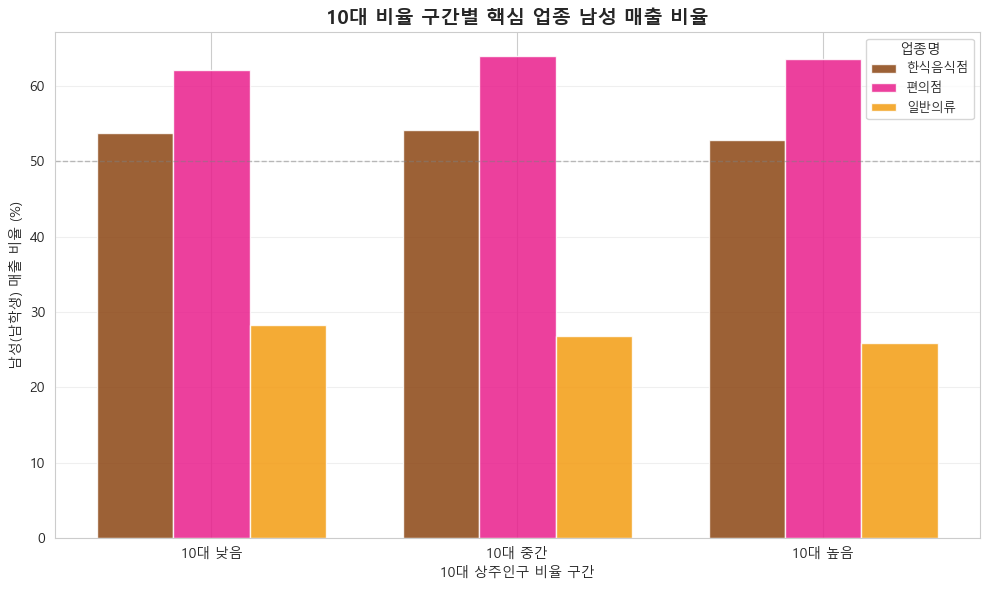

In [27]:
# %% 10대 상주 비율 구간별 업종 남성 매출 비율 시각화

# 1. 10대 남성 매출 데이터 집계 (성별_타겟_10 활용)
성별결과_10_남성 = 성별_타겟_10.groupby(['서비스_업종_코드_명', '10대_상주_구간'])['남성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(10, 6))

# 💡 여학생 차트와 완벽하게 동일한 색상 매핑 (한식: 브라운, 편의점: 핑크, 의류: 오렌지)
업종색 = {'한식음식점': '#8B4513', '편의점': '#E91E8C', '일반의류': '#F39C12'}
타겟3_10대 = ['한식음식점', '편의점', '일반의류']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 # 막대 너비
 
# 3. 업종별 막대 그래프 생성 (남성비율 기준)
for i, 업종 in enumerate(타겟3_10대):
    sub = 성별결과_10_남성[성별결과_10_남성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대를 나란히 배치
    ax.bar(x + i*w - w, sub['남성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['10대 낮음', '10대 중간', '10대 높음'])

ax.set_ylabel('남성(남학생) 매출 비율 (%)')
ax.set_xlabel('10대 상주인구 비율 구간')
ax.set_title('10대 비율 구간별 핵심 업종 남성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선 (이 선을 넘으면 남학생 소비가 주도적임을 의미)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
# %% 10대 시간대 분석
# 1. 10대 타겟 업종 데이터 필터링 및 시간대별 매출 집계
타겟3_10대 = ['한식음식점', '편의점', '일반의류']
시간_매출_cols = [c for c in sales.columns if '시간대' in c and '매출_금액' in c] # 시간대 컬럼 자동 추출

시간_타겟_10 = sales[sales['서비스_업종_코드_명'].isin(타겟3_10대)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[시간_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 10대 상주인구 비율 데이터와 병합 (df_상주 활용)
시간_타겟_10 = 시간_타겟_10.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '10대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 10대 상주 비율 기준 3구간 분할
시간_타겟_10['10대_상주_구간'] = pd.qcut(
    시간_타겟_10['10대_상주_비율'].dropna(), q=3,
    labels=['10대 낮음', '10대 중간', '10대 높음'], duplicates='drop'
)

# 시간대 라벨 설정 (출력용)
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']

# 4. 결과 출력
print('\n📊 10대 상주 구간 × 업종 × 시간대 매출 비중')
for 업종 in 타겟3_10대:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 시간라벨:
        print(f' {l:>7}', end='')
    print()
    
    for 구간 in ['10대 낮음', '10대 중간', '10대 높음']:
        sub = 시간_타겟_10[(시간_타겟_10['서비스_업종_코드_명'] == 업종) & (시간_타겟_10['10대_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 시간_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>6.1f}%', end='')
        print()


📊 10대 상주 구간 × 업종 × 시간대 매출 비중

▸ 한식음식점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  10대 낮음          3.0%    2.4%   28.0%   10.9%   40.9%   14.8%
  10대 중간          2.5%    2.3%   27.7%   11.4%   42.2%   14.0%
  10대 높음          1.8%    2.1%   31.2%   11.4%   40.9%   12.6%

▸ 편의점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  10대 낮음         10.7%   15.2%   13.7%   14.0%   27.4%   18.9%
  10대 중간         10.8%   15.3%   13.1%   13.8%   27.7%   19.4%
  10대 높음          9.3%   15.5%   13.6%   14.4%   27.9%   19.3%

▸ 일반의류
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  10대 낮음          0.4%    3.8%   24.2%   38.3%   30.5%    2.8%
  10대 중간          0.2%    3.5%   23.3%   38.9%   32.0%    2.1%
  10대 높음          0.2%    3.4%   22.2%   39.8%   32.3%    2.2%


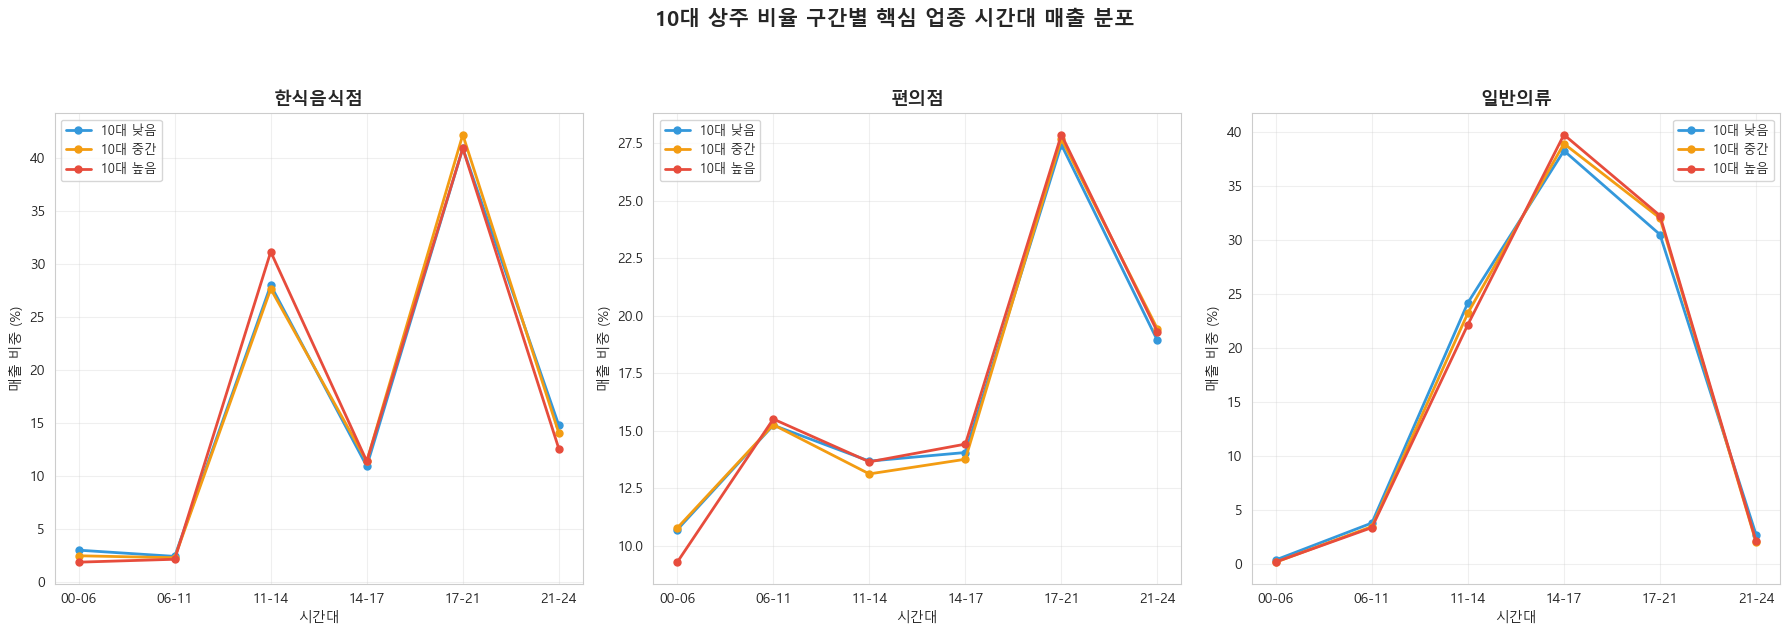

In [29]:
# %% 10대 상주 비율 구간별 업종 시간대 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 💡 분석 대상 10대 타겟 업종 정의
타겟3_10대 = ['한식음식점', '편의점', '일반의류']

for idx, 업종 in enumerate(타겟3_10대):
    ax = axes[idx]
    # 구간별 색상 통일 (낮음: 파랑, 중간: 주황, 높음: 빨강)
    구간색 = {'10대 낮음': '#3498DB', '10대 중간': '#F39C12', '10대 높음': '#E74C3C'}

    for 구간 in ['10대 낮음', '10대 중간', '10대 높음']:
        # 해당 업종과 10대 구간 필터링
        sub = 시간_타겟_10[(시간_타겟_10['서비스_업종_코드_명'] == 업종) & 
                           (시간_타겟_10['10대_상주_구간'] == 구간)]
        
        # 시간대별 매출 비중 평균 계산
        # (이전 코드에서 정의된 시간_매출_cols와 시간라벨 변수를 사용합니다)
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 시간_매출_cols]
        
        # 꺾은선 그래프 그리기
        ax.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)

    # 개별 차트 디테일
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_xlabel('시간대')
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# 전체 타이틀 및 레이아웃 조정
fig.suptitle('10대 상주 비율 구간별 핵심 업종 시간대 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [30]:
# %% 10대 요일 분석
# 1. 10대 타겟 업종 데이터 필터링 및 요일별 매출 집계
타겟3_10대 = ['한식음식점', '편의점', '일반의류']
요일_매출_cols = [c for c in sales.columns if '요일' in c and '매출_금액' in c] 

요일_타겟_10 = sales[sales['서비스_업종_코드_명'].isin(타겟3_10대)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[요일_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 10대 상주인구 비율 데이터와 병합 (df_상주 활용)
요일_타겟_10 = 요일_타겟_10.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '10대_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 10대 상주 비율 기준 3구간 분할
요일_타겟_10['10대_상주_구간'] = pd.qcut(
    요일_타겟_10['10대_상주_비율'].dropna(), q=3,
    labels=['10대 낮음', '10대 중간', '10대 높음'], duplicates='drop'
)

# 요일 라벨 설정 (출력용)
요일라벨 = ['월', '화', '수', '목', '금', '토', '일']

# 4. 결과 출력
print('\n📊 10대 상주 구간 × 업종 × 요일 매출 비중')
for 업종 in 타겟3_10대:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 요일라벨:
        print(f' {l:>6}', end='')
    print()
    
    for 구간 in ['10대 낮음', '10대 중간', '10대 높음']:
        sub = 요일_타겟_10[(요일_타겟_10['서비스_업종_코드_명'] == 업종) & (요일_타겟_10['10대_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 요일_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>5.1f}%', end='')
        print()


📊 10대 상주 구간 × 업종 × 요일 매출 비중

▸ 한식음식점
  구간                월      화      수      목      금      토      일
  10대 낮음        13.3%  14.2%  14.7%  14.9%  16.5%  15.4%  10.9%
  10대 중간        13.0%  14.0%  14.4%  14.5%  16.2%  16.0%  11.9%
  10대 높음        13.2%  14.2%  14.6%  14.8%  16.2%  15.6%  11.4%

▸ 편의점
  구간                월      화      수      목      금      토      일
  10대 낮음        14.1%  14.3%  14.5%  14.6%  15.7%  14.4%  12.4%
  10대 중간        14.0%  14.2%  14.3%  14.4%  15.5%  14.6%  13.0%
  10대 높음        14.1%  14.2%  14.4%  14.5%  15.5%  14.5%  12.9%

▸ 일반의류
  구간                월      화      수      목      금      토      일
  10대 낮음        13.6%  14.2%  14.9%  15.4%  15.9%  16.0%  10.0%
  10대 중간        13.7%  15.0%  15.5%  15.3%  16.1%  15.7%   8.6%
  10대 높음        14.1%  15.6%  15.8%  16.0%  16.2%  15.2%   7.1%


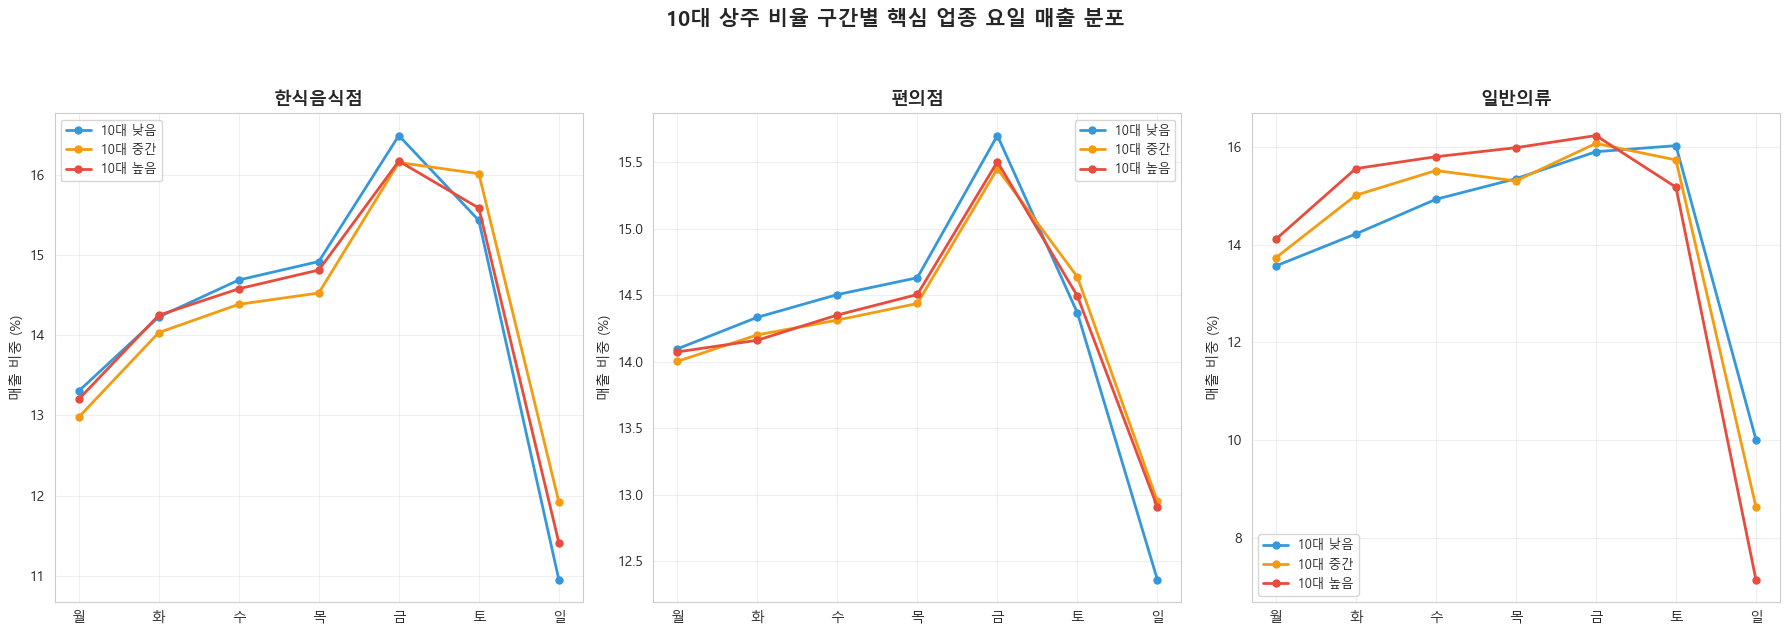

In [31]:
# %% 10대 상주 비율 구간별 업종 요일 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 💡 분석 대상 10대 타겟 업종 정의
타겟3_10대 = ['한식음식점', '편의점', '일반의류']
 
for idx, 업종 in enumerate(타겟3_10대):
    ax = axes[idx]
    # 구간별 색상 통일 (낮음: 파랑, 중간: 주황, 높음: 빨강)
    구간색 = {'10대 낮음': '#3498DB', '10대 중간': '#F39C12', '10대 높음': '#E74C3C'}
 
    for 구간 in ['10대 낮음', '10대 중간', '10대 높음']:
        # 해당 업종과 10대 구간 필터링
        sub = 요일_타겟_10[(요일_타겟_10['서비스_업종_코드_명'] == 업종) & 
                           (요일_타겟_10['10대_상주_구간'] == 구간)]
        
        # 요일별 매출 비중 평균 계산 (요일_매출_cols와 요일라벨 활용)
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 요일_매출_cols]
        
        # 꺾은선 그래프 생성
        ax.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)
 
    # 차트 개별 설정
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
# 전체 제목 및 레이아웃 정리
fig.suptitle('10대 상주 비율 구간별 핵심 업종 요일 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()